# Exploratory Data Analysis — Patient Readmission

Dataset: `domain1/temp/cleaned_dataSet.csv`
Target: `readmission_flag` (0 = not readmitted, 1 = readmitted)
`patient_id` is a reference identifier only and is excluded from all statistical/correlation/distribution analysis.

This notebook profiles the data and reports data-driven findings only. No modeling or feature engineering is performed here.

In [2]:
%pip install -q numpy pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

DATA_PATH = Path("../temp/cleaned_dataSet.csv")
df = pd.read_csv(DATA_PATH)

ID_COL = 'patient_id'
TARGET = 'readmission_flag'

NUMERIC_FEATURES = [
    'age', 'bmi', 'length_of_stay_days', 'previous_admissions_12m',
    'chronic_conditions_count', 'blood_glucose', 'cholesterol_level',
    'hemoglobin', 'creatinine', 'medications_count', 'treatment_cost',
    'patient_education_score', 'number_of_procedures', 'medication_changes_during_stay'
]

CATEGORICAL_FEATURES = [
    'gender', 'smoking_status', 'diabetes_flag', 'hypertension_flag',
    'heart_disease_flag', 'icu_admission_flag', 'emergency_admission_flag',
    'high_risk_medication_flag', 'followup_scheduled_flag',
    'discharge_destination', 'insurance_type'
]

ANALYSIS_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]

df.shape


(50000, 27)

## 1. Data Overview

### 1.1 Shape and dtypes

In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
dtypes_table = df.dtypes.rename('dtype').to_frame()
dtypes_table

Rows: 50000, Columns: 27


,dtype
patient_id,int64
age,int64
gender,str
bmi,float64
smoking_status,str
diabetes_flag,int64
hypertension_flag,int64
heart_disease_flag,int64
chronic_conditions_count,int64
previous_admissions_12m,int64


27 columns, 50,000 rows. Four columns (`gender`, `smoking_status`, `discharge_destination`, `insurance_type`) are stored as strings — everything else, including all the flag columns, is already int64/float64. That's why those four are the ones treated as categorical below and the rest as numeric; `patient_id` is excluded regardless.

### 1.2 Descriptive statistics — numeric features

In [5]:
numeric_desc = df[NUMERIC_FEATURES].describe().T
numeric_desc

,count,mean,std,min,25%,50%,75%,max
age,50000.0,53.398700,20.799006,18.000000,35.000000,53.000000,71.000000,89.000000
bmi,50000.0,27.036777,5.814111,15.000000,22.978358,27.003465,31.054612,40.854544
length_of_stay_days,50000.0,9.984500,5.471034,1.000000,5.000000,10.000000,15.000000,19.000000
previous_admissions_12m,50000.0,0.999220,0.985372,0.000000,0.000000,1.000000,2.000000,4.000000
chronic_conditions_count,50000.0,1.985080,1.392715,0.000000,1.000000,2.000000,3.000000,6.000000
blood_glucose,50000.0,120.157670,39.337152,27.627714,93.269896,120.037222,147.143915,214.040377
cholesterol_level,50000.0,190.091804,37.204868,99.648870,166.384416,190.088815,213.779313,281.402962
hemoglobin,50000.0,12.990101,1.866189,8.377383,11.808503,12.986089,14.171411,17.581129
creatinine,50000.0,1.097703,0.491519,-0.061471,0.760750,1.094773,1.434672,2.274000
medications_count,50000.0,5.016400,2.203476,1.000000,3.000000,5.000000,6.000000,11.000000


Most numeric features have tight, plausible ranges (e.g. `age` 18-89, `bmi` 15-41). Two things stand out: `creatinine`'s minimum is negative (-0.06), which shouldn't happen for this kind of measurement, and `treatment_cost`/`medication_changes_during_stay` have maxes far above their 75th percentile (119k vs 63k; 12 vs 3) — a right-skew that shows up again in the histograms and boxplots below.

### 1.3 Descriptive statistics — categorical/flag features

In [6]:
categorical_desc = df[CATEGORICAL_FEATURES].describe(include='all').T
categorical_desc

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,50000,2,male,25047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,50000,3,former,16777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes_flag,50000.0,NaN,NaN,NaN,0.29918,0.457903,0.0,0.0,0.0,1.0,1.0
hypertension_flag,50000.0,NaN,NaN,NaN,0.40162,0.490231,0.0,0.0,0.0,1.0,1.0
heart_disease_flag,50000.0,NaN,NaN,NaN,0.20126,0.400946,0.0,0.0,0.0,0.0,1.0
icu_admission_flag,50000.0,NaN,NaN,NaN,0.15096,0.358013,0.0,0.0,0.0,0.0,1.0
emergency_admission_flag,50000.0,NaN,NaN,NaN,0.30052,0.458489,0.0,0.0,0.0,1.0,1.0
high_risk_medication_flag,50000.0,NaN,NaN,NaN,0.2033,0.402458,0.0,0.0,0.0,0.0,1.0
followup_scheduled_flag,50000.0,NaN,NaN,NaN,0.69762,0.459294,0.0,0.0,1.0,1.0,1.0
discharge_destination,50000,4,other hospital,12564,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`gender`, `smoking_status`, `discharge_destination` and `insurance_type` are all close to evenly split across their categories (top category is only 25-50% of rows). The binary flags are more one-sided: `followup_scheduled_flag` is 1 for ~70% of rows, while `icu_admission_flag` (~15%), `heart_disease_flag` (~20%) and `high_risk_medication_flag` (~20%) are mostly 0.

## 2. Target Variable Analysis

                  count    pct
readmission_flag              
0                 32659  65.32
1                 17341  34.68


C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\1040802199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=ax, palette='Set2')


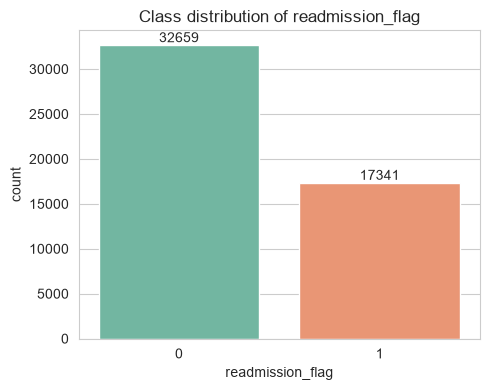

In [7]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(2)
target_summary = pd.DataFrame({'count': target_counts, 'pct': target_pct})
print(target_summary)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=ax, palette='Set2')
ax.set_xlabel('readmission_flag')
ax.set_ylabel('count')
ax.set_title('Class distribution of readmission_flag')
for i, v in enumerate(target_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

Target is imbalanced: 65.3% not readmitted vs 34.7% readmitted, roughly a 2:1 split. Category-level readmission rates in Section 4 should be compared against this ~35% baseline, not 50%.

## 3. Univariate Analysis

### 3.1 Numeric feature distributions (histograms)

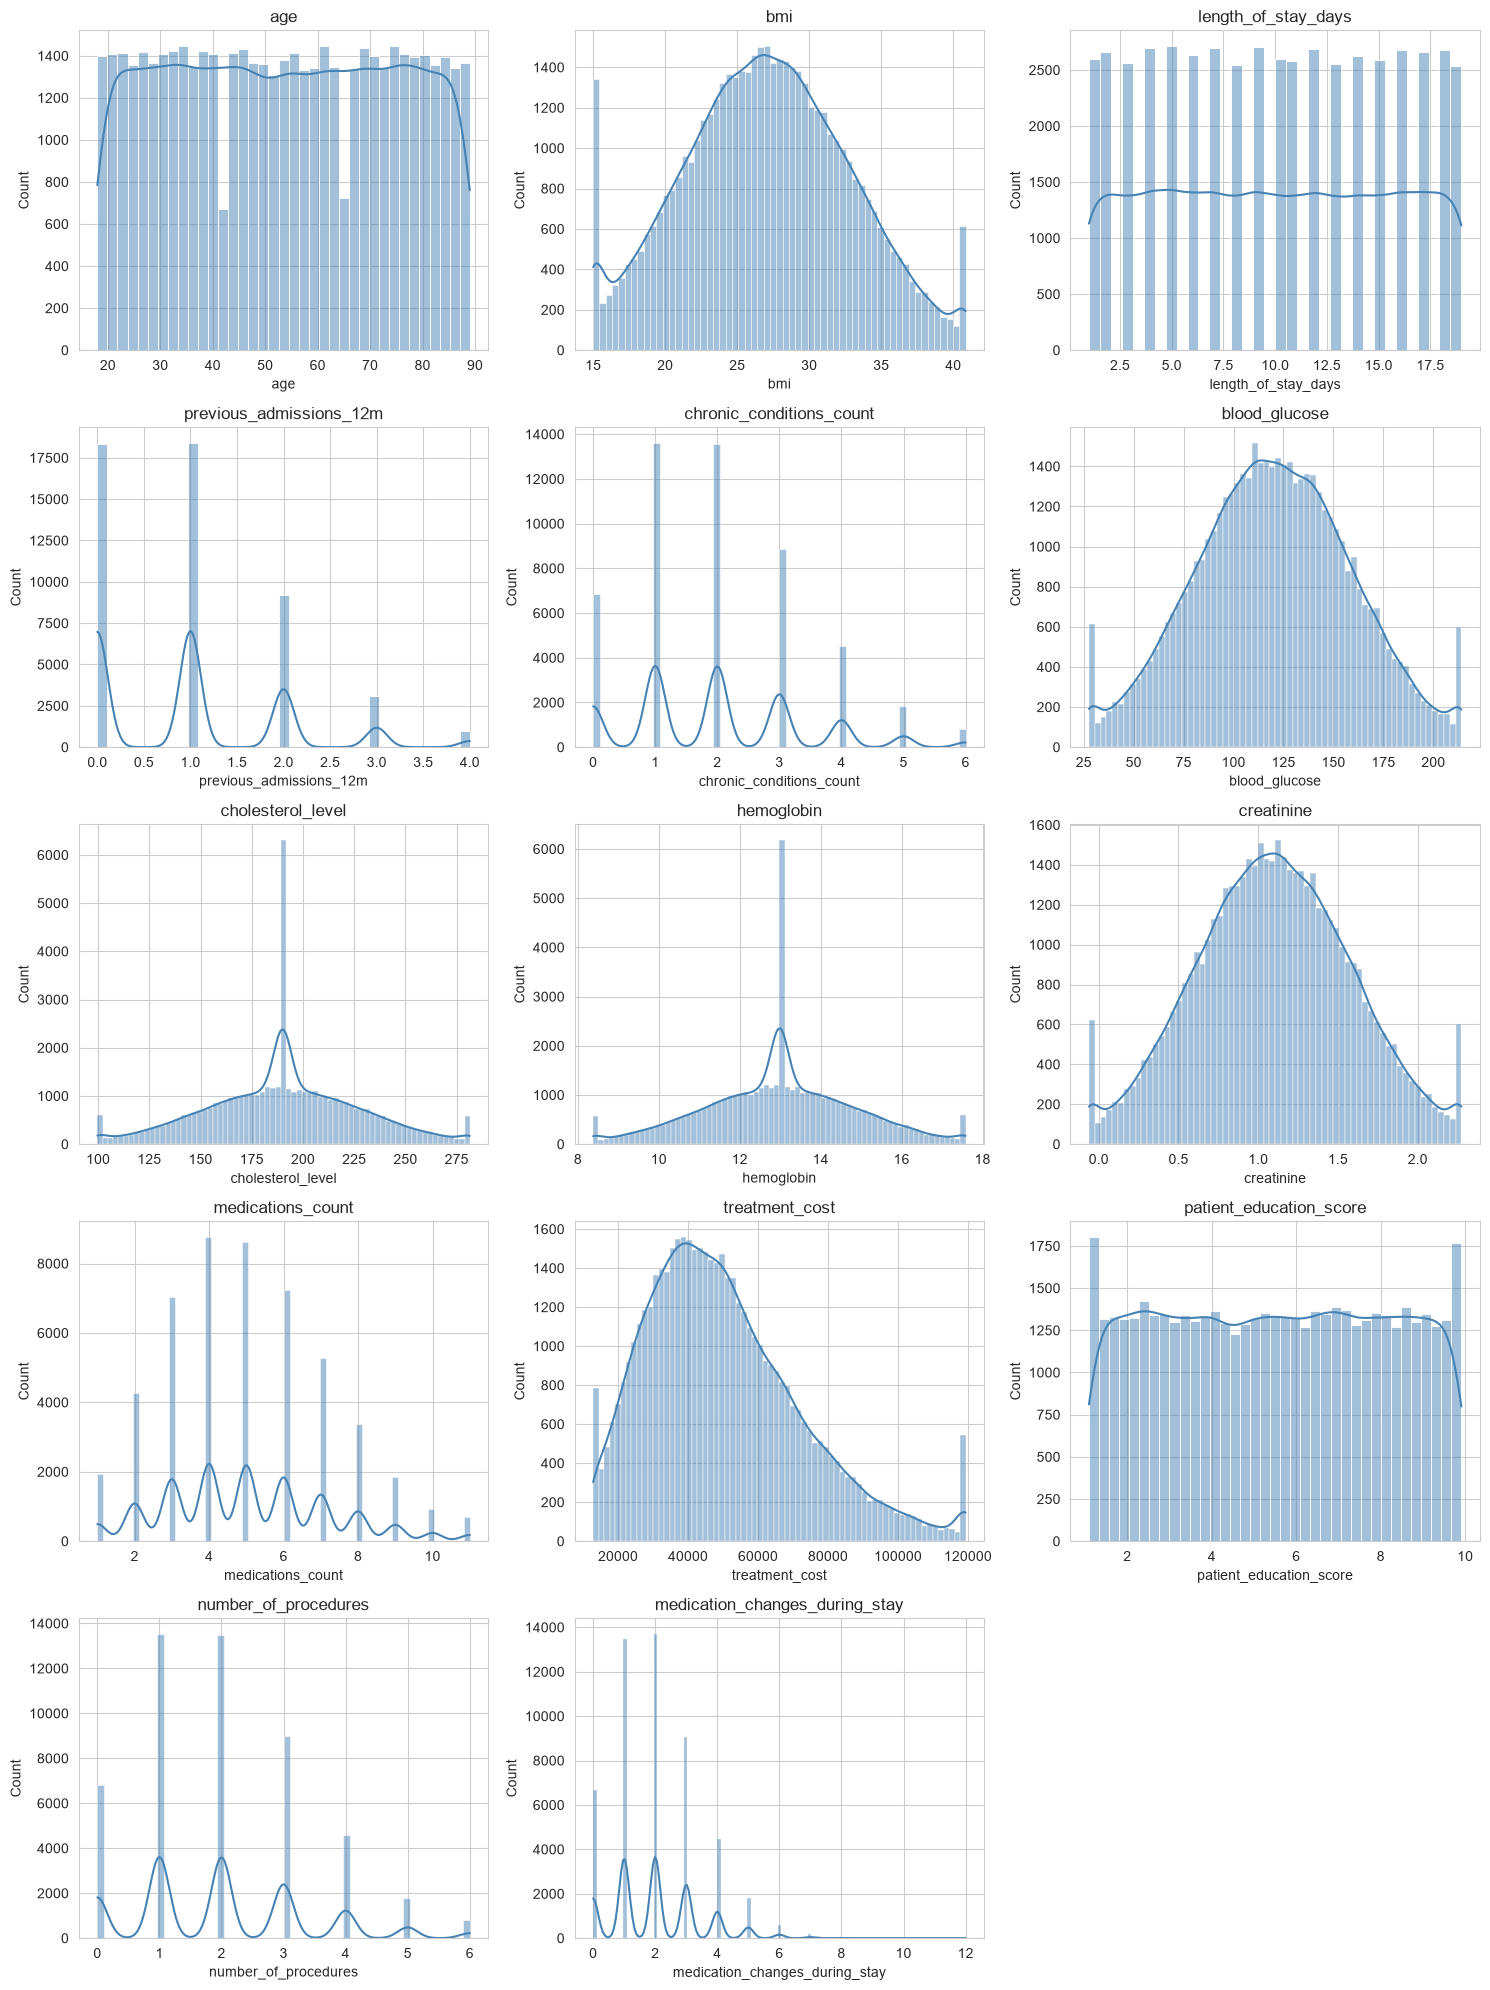

,skewness
previous_admissions_12m,0.871677
treatment_cost,0.777084
medication_changes_during_stay,0.698734
chronic_conditions_count,0.599691
number_of_procedures,0.593323
medications_count,0.391871
bmi,0.055032
creatinine,0.023275
blood_glucose,0.009403
length_of_stay_days,0.005495


In [8]:
n_cols = 3
n_rows = int(np.ceil(len(NUMERIC_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATURES):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
for j in range(len(NUMERIC_FEATURES), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

skew_table = df[NUMERIC_FEATURES].skew().sort_values(ascending=False).rename('skewness').to_frame()
skew_table

Skewness sits near 0 for the continuous features (`age`, `bmi`, `blood_glucose`, `cholesterol_level`, `hemoglobin`, `creatinine`, `length_of_stay_days`, `patient_education_score`) — their histograms look roughly symmetric/uniform. The count-style features are the most right-skewed: `previous_admissions_12m` (0.87), `treatment_cost` (0.78), `medication_changes_during_stay` (0.70), `chronic_conditions_count` (0.60) and `number_of_procedures` (0.59), all peaking near 0-2 with a thinning tail toward higher values.

### 3.2 Numeric feature distributions (boxplots — outlier check)

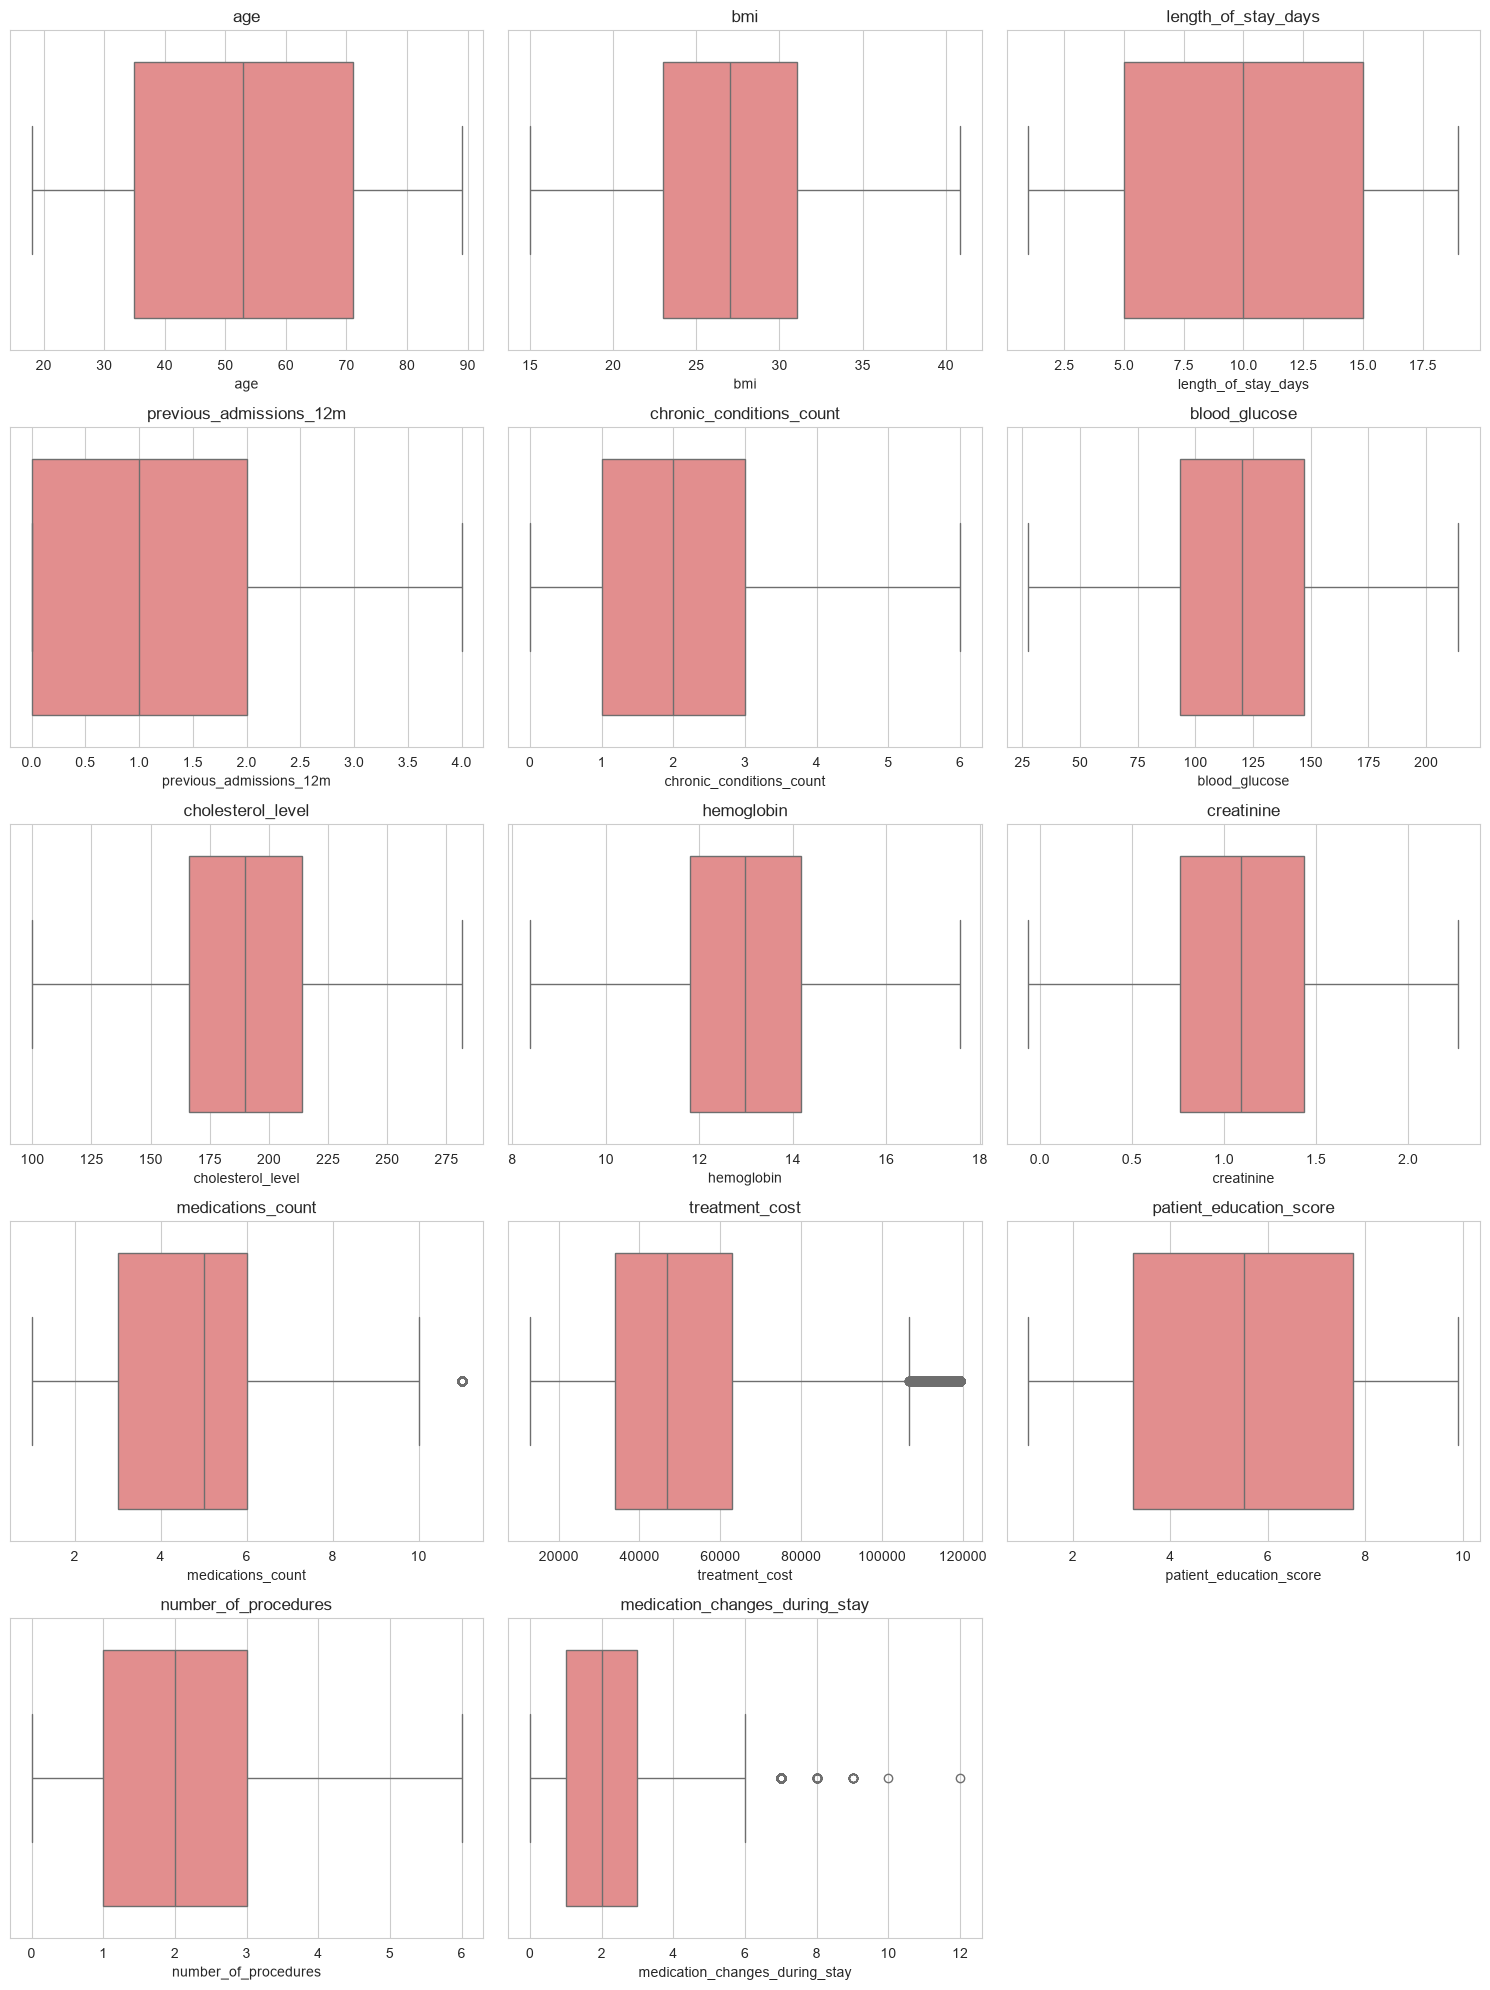

,iqr_outlier_count,outlier_pct
treatment_cost,1033,2.07
medications_count,693,1.39
medication_changes_during_stay,212,0.42
length_of_stay_days,0,0.00
age,0,0.00
bmi,0,0.00
blood_glucose,0,0.00
chronic_conditions_count,0,0.00
previous_admissions_12m,0,0.00
cholesterol_level,0,0.00


In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATURES):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(len(NUMERIC_FEATURES), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = pd.Series({col: iqr_outlier_count(df[col]) for col in NUMERIC_FEATURES}, name='iqr_outlier_count')
outlier_pct = (outlier_counts / len(df) * 100).round(2).rename('outlier_pct')
outlier_table = pd.concat([outlier_counts, outlier_pct], axis=1).sort_values('iqr_outlier_count', ascending=False)
outlier_table

IQR outliers only show up in three features: `treatment_cost` (2.07% of rows), `medications_count` (1.39%) and `medication_changes_during_stay` (0.42%) — these are the dots beyond the whiskers in the boxplots. Every other numeric feature has 0 flagged outliers under the 1.5×IQR rule.

### 3.3 Categorical/flag feature distributions

C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\3862534479.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[i], palette='viridis')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\3862534479.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[i], palette='viridis')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\3862534479.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[i], palette='viridis')
C:\U

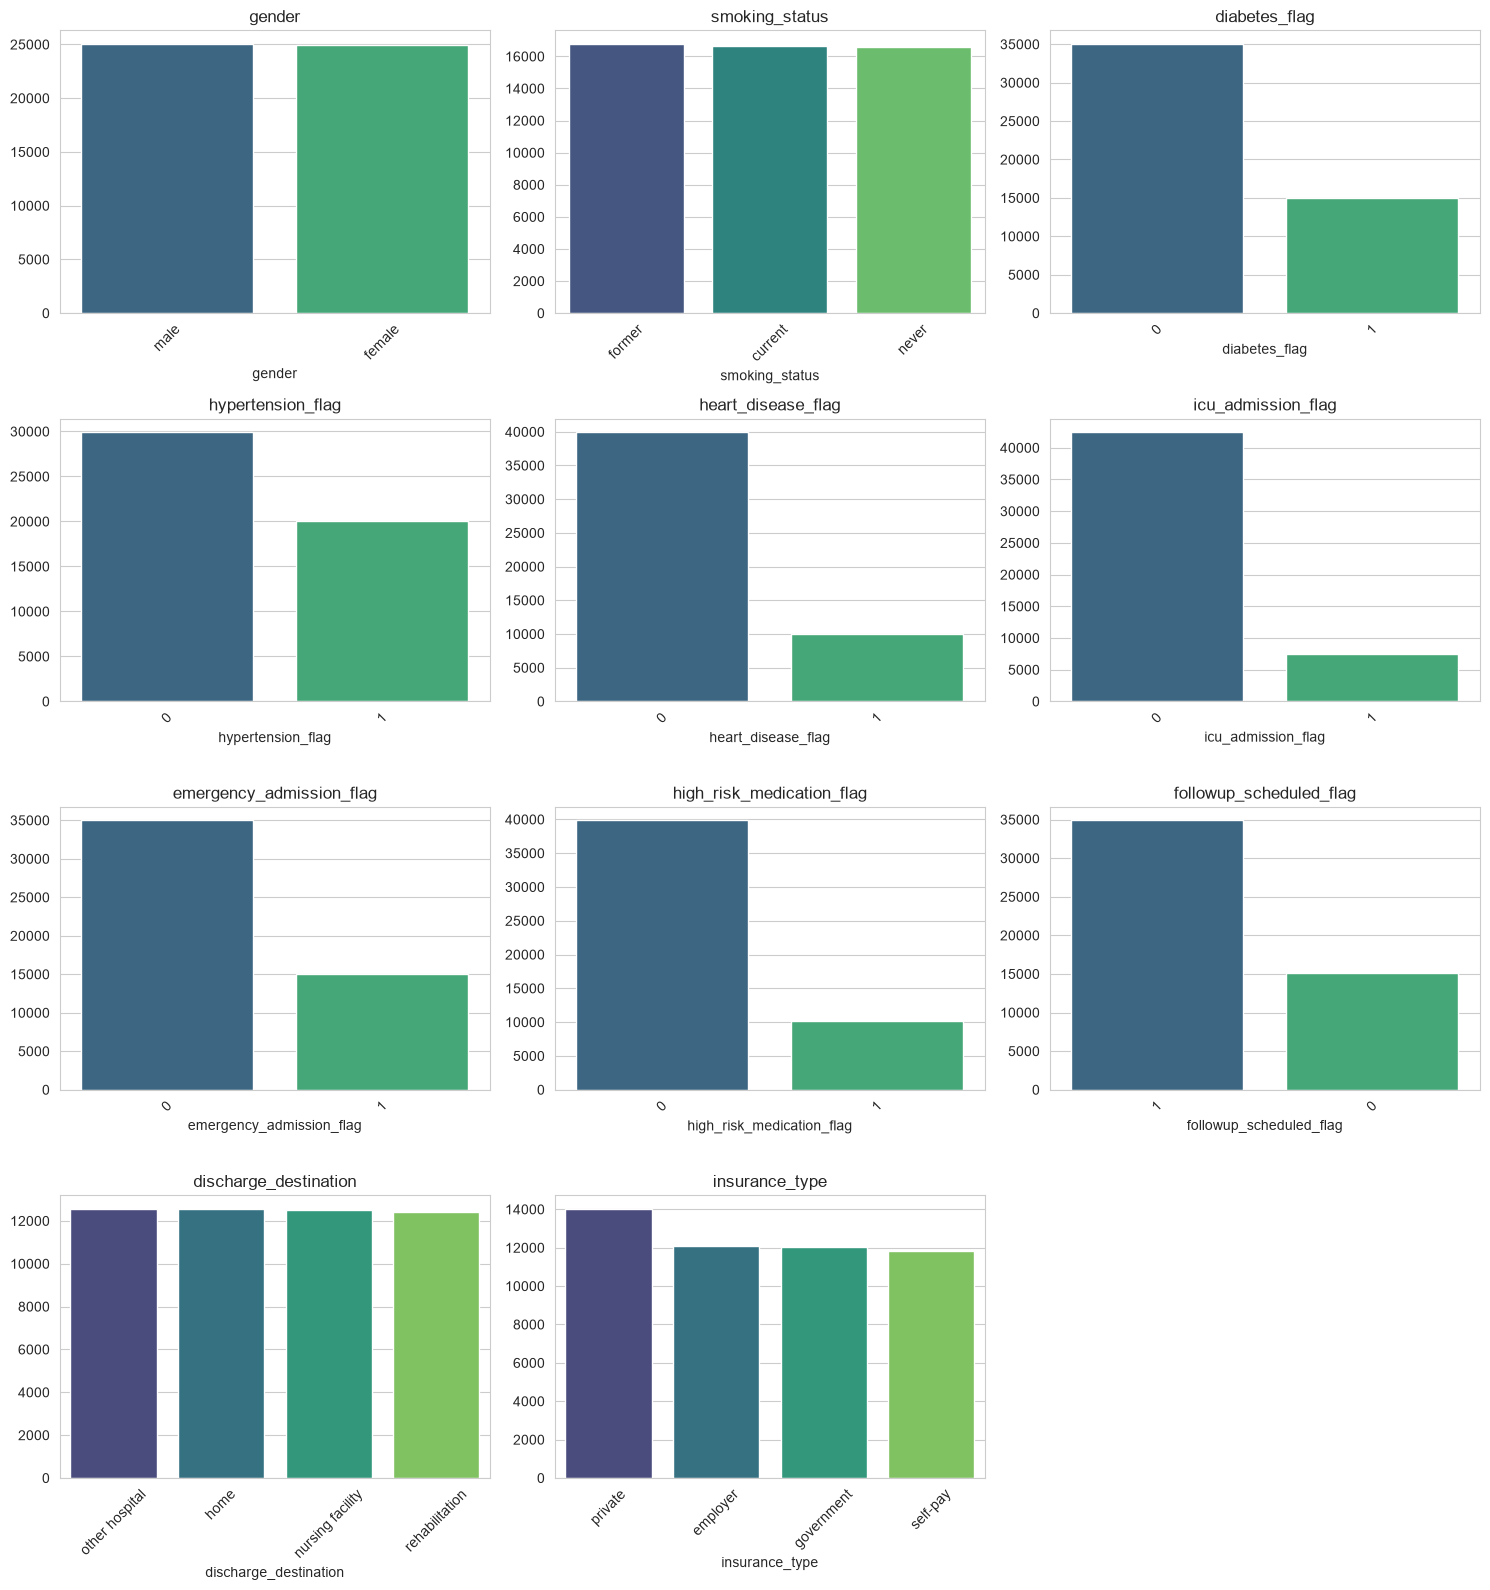

In [10]:
n_cols2 = 3
n_rows2 = int(np.ceil(len(CATEGORICAL_FEATURES) / n_cols2))
fig, axes = plt.subplots(n_rows2, n_cols2, figsize=(15, 4 * n_rows2))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL_FEATURES):
    vc = df[col].value_counts()
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[i], palette='viridis')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(CATEGORICAL_FEATURES), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The four text columns (`gender`, `smoking_status`, `discharge_destination`, `insurance_type`) all have fairly even bars across their levels. The binary flags split unevenly instead — `followup_scheduled_flag` skews toward 1, while `icu_admission_flag`, `heart_disease_flag` and `high_risk_medication_flag` skew toward 0 — the same pattern already seen in the Section 1.3 table.

## 4. Bivariate Analysis vs `readmission_flag`

### 4.1 Numeric features grouped by `readmission_flag`

In [11]:
grouped_stats = df.groupby(TARGET)[NUMERIC_FEATURES].mean().T
grouped_stats.columns = [f'mean_readmit_{c}' for c in grouped_stats.columns]
grouped_stats['mean_diff (1 - 0)'] = grouped_stats['mean_readmit_1'] - grouped_stats['mean_readmit_0']
grouped_stats = grouped_stats.sort_values('mean_diff (1 - 0)', key=abs, ascending=False)
grouped_stats

,mean_readmit_0,mean_readmit_1,mean_diff (1 - 0)
treatment_cost,50186.446553,50034.756449,-151.690104
age,50.848342,58.201891,7.353550
length_of_stay_days,9.299213,11.275128,1.975915
patient_education_score,6.031040,4.482508,-1.548532
chronic_conditions_count,1.805995,2.322357,0.516362
previous_admissions_12m,0.909366,1.168445,0.259078
cholesterol_level,190.023606,190.220246,0.196640
blood_glucose,120.145065,120.181411,0.036347
hemoglobin,12.999812,12.971811,-0.028001
medications_count,5.007594,5.032985,0.025392


C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\2401398812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\2401398812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\2401398812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12

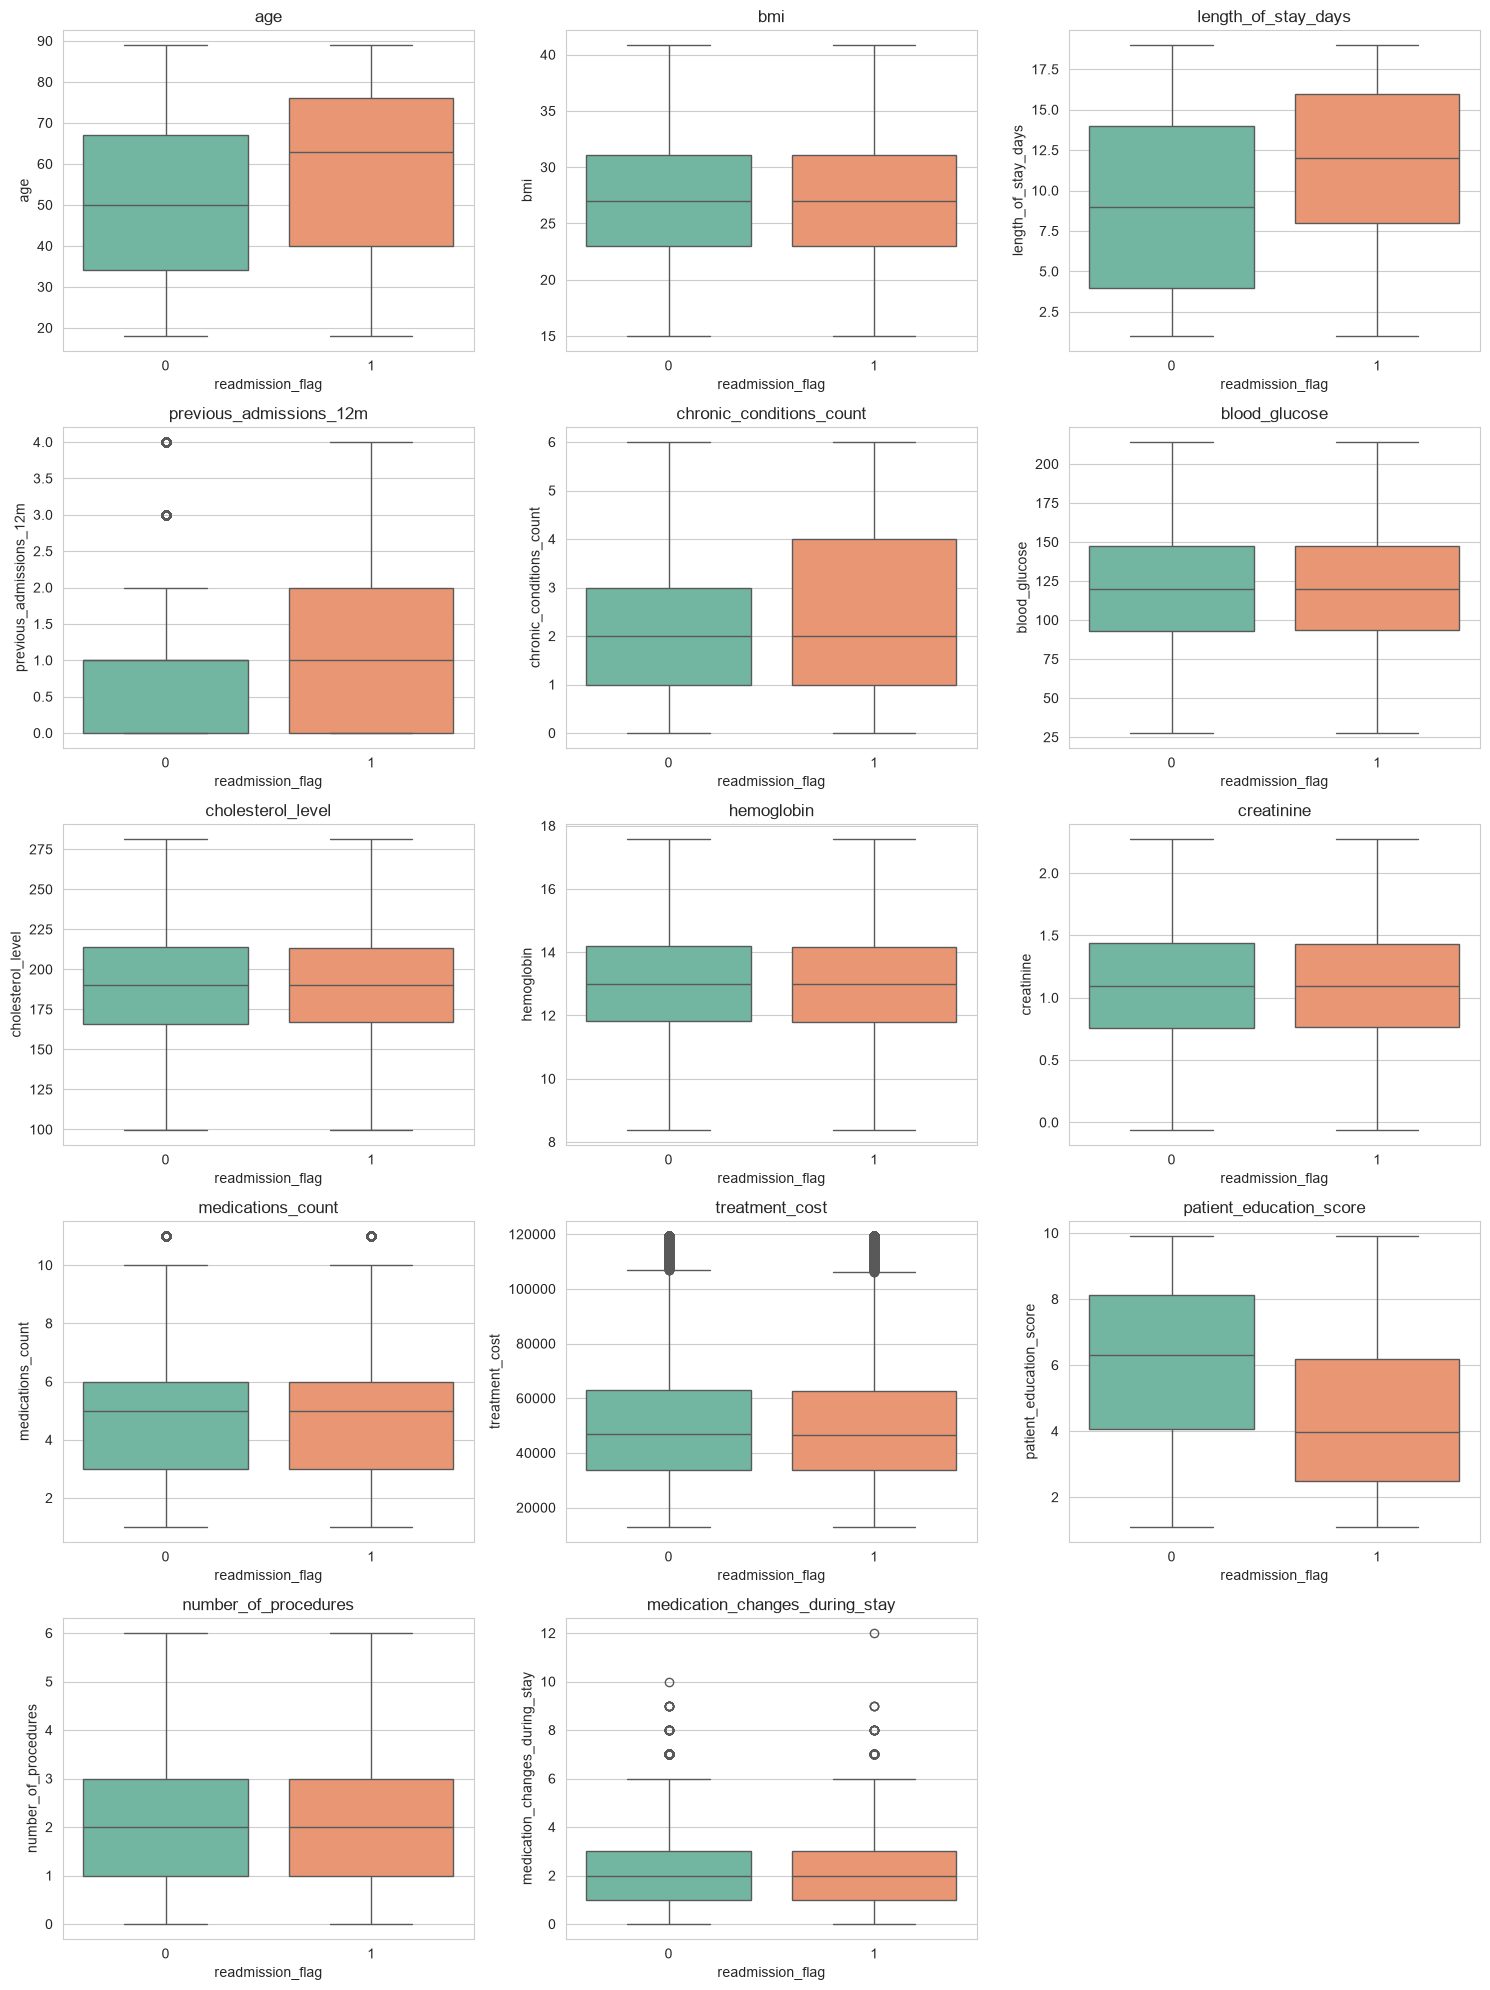

In [12]:
n_rows3 = int(np.ceil(len(NUMERIC_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows3, n_cols, figsize=(15, 4 * n_rows3))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATURES):
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
for j in range(len(NUMERIC_FEATURES), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

`age` has the largest mean gap between classes — 58.2 for readmitted vs 50.8 for not, a +7.4 difference — followed by `length_of_stay_days` (+2.0) and `patient_education_score` (-1.5, lower for readmitted). The remaining numeric features all differ by under 0.6 in their own units, matching how similar their boxplots look between the two `readmission_flag` groups.

### 4.2 Categorical/flag features — readmission rate per category

C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\2974955979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette='rocket')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\2974955979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette='rocket')
C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\2974955979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette='rock

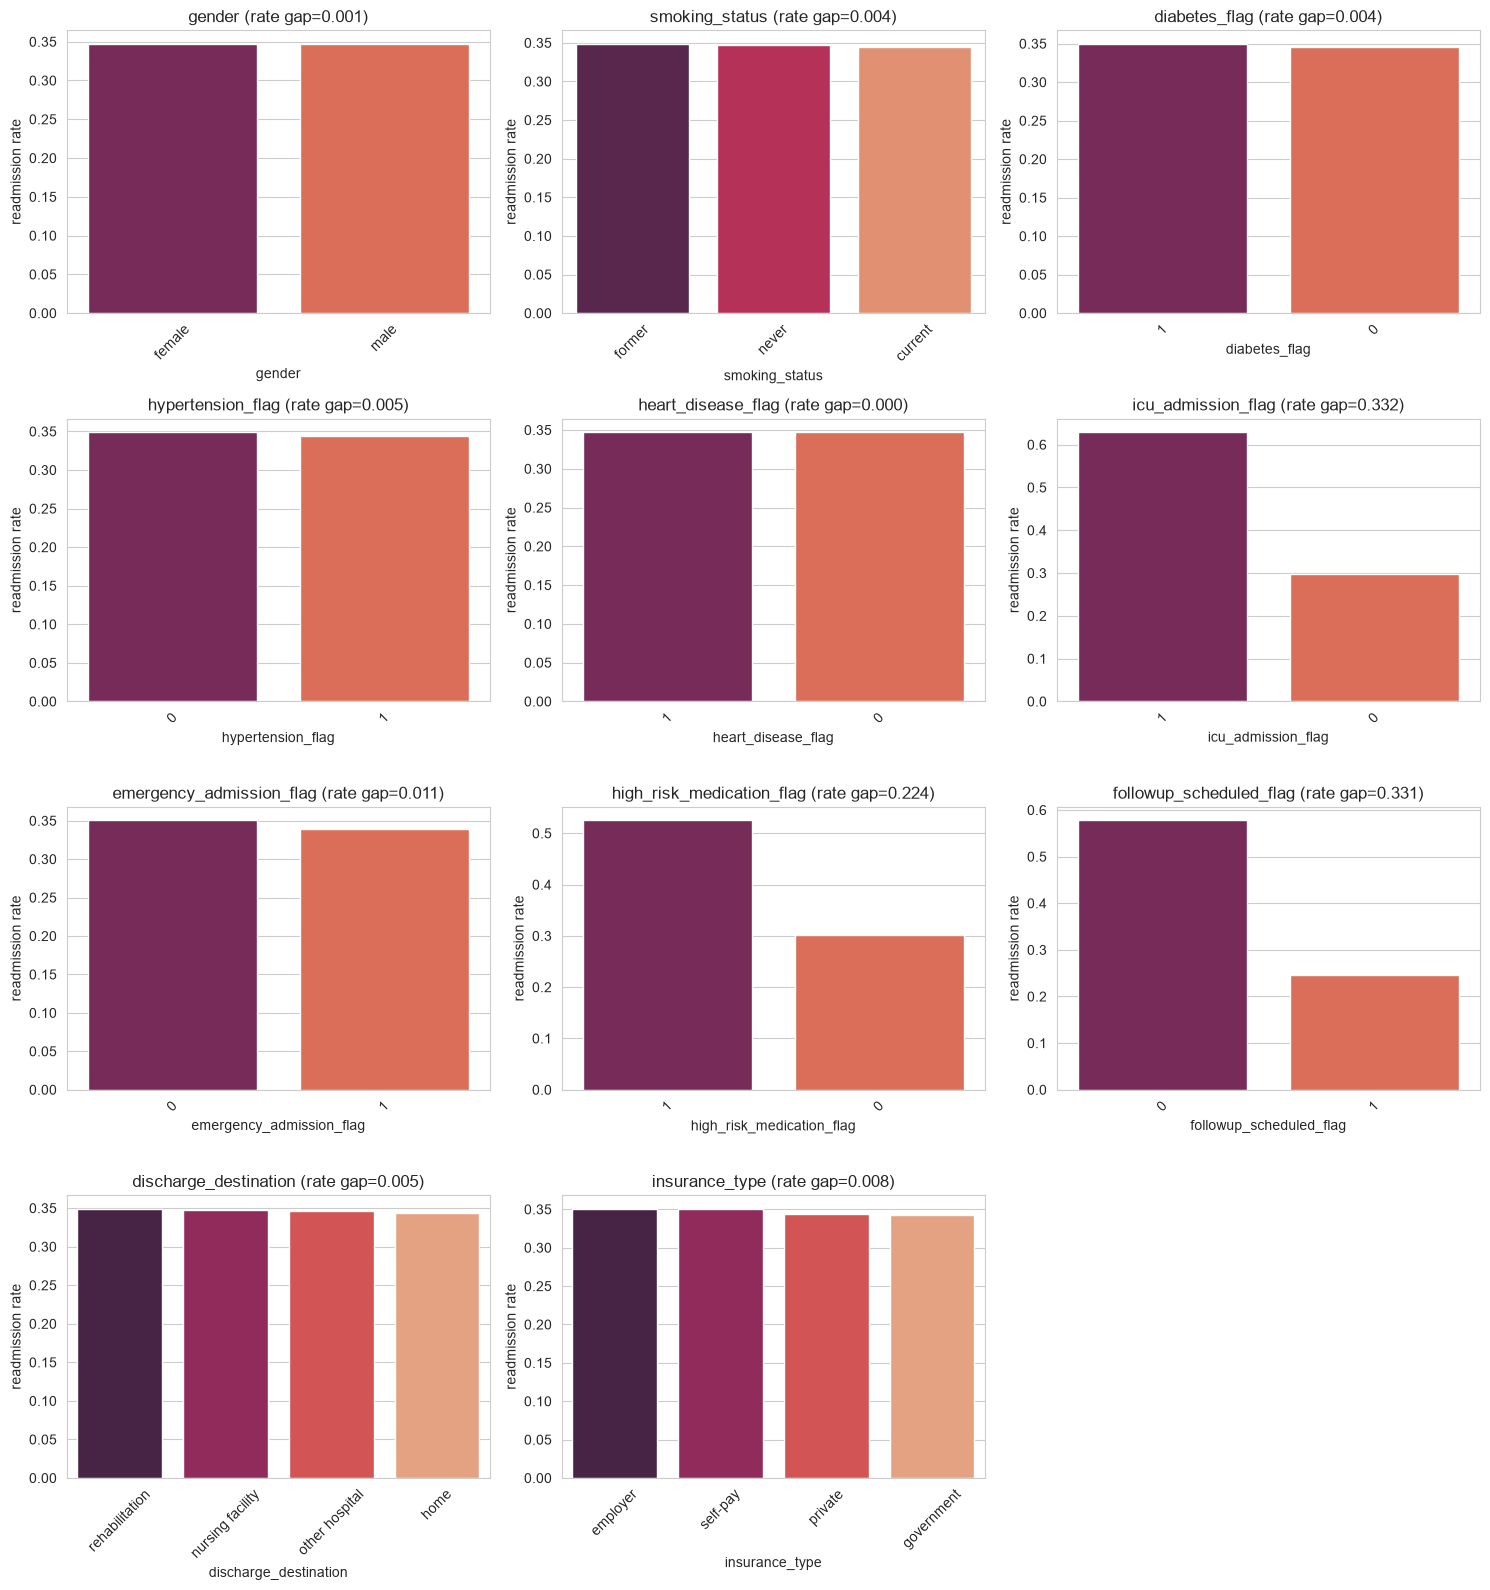

,readmission_rate_gap
icu_admission_flag,0.332400
followup_scheduled_flag,0.330646
high_risk_medication_flag,0.223570
emergency_admission_flag,0.011447
insurance_type,0.007701
hypertension_flag,0.005367
discharge_destination,0.005317
diabetes_flag,0.003999
smoking_status,0.003811
gender,0.000624


In [13]:
readmit_rate_gap = {}
fig, axes = plt.subplots(n_rows2, n_cols2, figsize=(15, 4 * n_rows2))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL_FEATURES):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    readmit_rate_gap[col] = rate.max() - rate.min()
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette='rocket')
    axes[i].set_title(f'{col} (rate gap={readmit_rate_gap[col]:.3f})')
    axes[i].set_ylabel('readmission rate')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(CATEGORICAL_FEATURES), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

rate_gap_table = pd.Series(readmit_rate_gap, name='readmission_rate_gap').sort_values(ascending=False).to_frame()
rate_gap_table

Three flags have a much bigger readmission-rate swing between their two levels than everything else: `icu_admission_flag` (gap 0.332 — 63% vs 30%), `followup_scheduled_flag` (gap 0.331 — 58% vs 24%) and `high_risk_medication_flag` (gap 0.224 — 52% vs 30%). Every other feature has a gap under 0.012, i.e. its categories have nearly identical readmission rates.

## 5. Correlation Analysis

### 5.1 Correlation matrix among numeric features

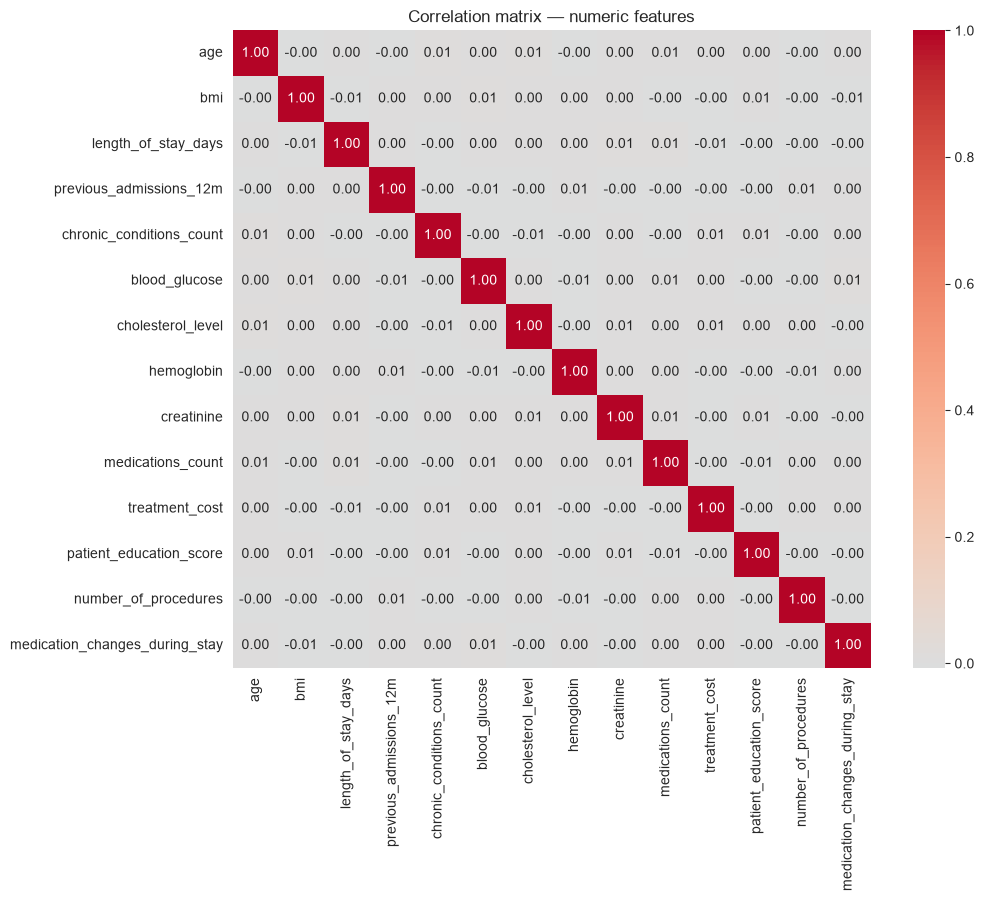

In [14]:
corr_matrix = df[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

Every off-diagonal cell rounds to 0.00-0.01 — none of these 14 numeric features are linearly correlated with each other in this dataset, so there's no redundant pair to flag from this matrix.

### 5.2 Correlation of numeric features with `readmission_flag`

C:\Users\jayan\AppData\Local\Temp\ipykernel_12320\3095261122.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm', ax=ax)


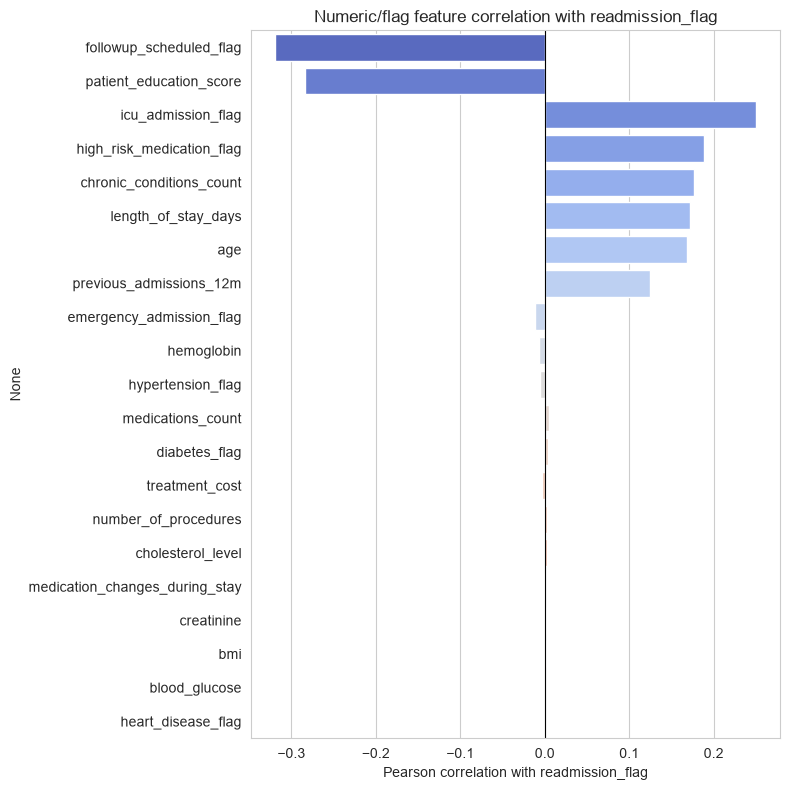

,corr_with_readmission_flag
followup_scheduled_flag,-0.319066
patient_education_score,-0.284355
icu_admission_flag,0.250027
high_risk_medication_flag,0.189044
chronic_conditions_count,0.176468
length_of_stay_days,0.171898
age,0.168278
previous_admissions_12m,0.125142
emergency_admission_flag,-0.011027
hemoglobin,-0.007141


In [15]:
flag_cols = ['diabetes_flag', 'hypertension_flag', 'heart_disease_flag', 'icu_admission_flag',
             'emergency_admission_flag', 'high_risk_medication_flag', 'followup_scheduled_flag']
all_numeric_like = NUMERIC_FEATURES + flag_cols

target_corr = df[all_numeric_like + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
target_corr_table = target_corr.rename('corr_with_readmission_flag').to_frame()

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm', ax=ax)
ax.set_xlabel('Pearson correlation with readmission_flag')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Numeric/flag feature correlation with readmission_flag')
plt.tight_layout()
plt.show()

target_corr_table

Eight features carry a non-trivial correlation with `readmission_flag`: `followup_scheduled_flag` (-0.32), `patient_education_score` (-0.28), `icu_admission_flag` (+0.25), `high_risk_medication_flag` (+0.19), `chronic_conditions_count` (+0.18), `length_of_stay_days` (+0.17), `age` (+0.17) and `previous_admissions_12m` (+0.13). The other 13 all sit under ±0.011 — essentially no linear association with the target.

### 5.3 Chi-square test of independence — categorical features vs `readmission_flag`

In [16]:
chi2_results = []
for col in CATEGORICAL_FEATURES:
    contingency = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({'feature': col, 'chi2_stat': chi2, 'p_value': p, 'dof': dof, 'significant_p<0.05': p < 0.05})

chi2_table = pd.DataFrame(chi2_results).sort_values('chi2_stat', ascending=False).reset_index(drop=True)
chi2_table

,feature,chi2_stat,p_value,dof,significant_p<0.05
0,followup_scheduled_flag,5088.702509,0.000000,1,True
1,icu_admission_flag,3124.214786,0.000000,1,True
2,high_risk_medication_flag,1785.886210,0.000000,1,True
3,emergency_admission_flag,6.029531,0.014068,1,True
4,insurance_type,2.773392,0.427899,3,False
5,hypertension_flag,1.504380,0.219999,1,False
6,discharge_destination,0.833743,0.841380,3,False
7,diabetes_flag,0.722381,0.395364,1,False
8,smoking_status,0.545390,0.761325,2,False
9,gender,0.018822,0.890878,1,False


Only 4 of the 11 categorical/flag features come back significant at p<0.05: `followup_scheduled_flag` (chi2=5089), `icu_admission_flag` (chi2=3124), `high_risk_medication_flag` (chi2=1786) and `emergency_admission_flag` (chi2=6.0, p=0.014). The other 7 (`insurance_type`, `hypertension_flag`, `discharge_destination`, `diabetes_flag`, `smoking_status`, `gender`, `heart_disease_flag`) all have p > 0.05.

## 6. Data-Driven Feature Ranking Summary

In [17]:
numeric_rank = target_corr_table.copy()
numeric_rank['abs_metric'] = numeric_rank['corr_with_readmission_flag'].abs()
numeric_rank['metric_type'] = 'pearson_corr_with_target'
numeric_rank = numeric_rank.rename(columns={'corr_with_readmission_flag': 'metric_value'}).reset_index().rename(columns={'index': 'feature'})

categorical_rank = chi2_table[['feature', 'chi2_stat', 'p_value']].copy()
categorical_rank['abs_metric'] = categorical_rank['chi2_stat']
categorical_rank['metric_type'] = 'chi2_stat_with_target'
categorical_rank = categorical_rank.rename(columns={'chi2_stat': 'metric_value'})

numeric_rank['pct_rank'] = numeric_rank['abs_metric'].rank(pct=True)
categorical_rank['pct_rank'] = categorical_rank['abs_metric'].rank(pct=True)

combined = pd.concat([
    numeric_rank[['feature', 'metric_type', 'metric_value', 'pct_rank']],
    categorical_rank[['feature', 'metric_type', 'metric_value', 'pct_rank']].assign(p_value=categorical_rank['p_value'])
], ignore_index=True)

combined = combined.sort_values('pct_rank', ascending=False).reset_index(drop=True)
combined.insert(0, 'overall_rank', combined.index + 1)
combined

,overall_rank,feature,metric_type,metric_value,pct_rank,p_value
0,1,followup_scheduled_flag,pearson_corr_with_target,-0.319066,1.000000,NaN
1,2,followup_scheduled_flag,chi2_stat_with_target,5088.702509,1.000000,0.000000
2,3,patient_education_score,pearson_corr_with_target,-0.284355,0.952381,NaN
3,4,icu_admission_flag,chi2_stat_with_target,3124.214786,0.909091,0.000000
4,5,icu_admission_flag,pearson_corr_with_target,0.250027,0.904762,NaN
5,6,high_risk_medication_flag,pearson_corr_with_target,0.189044,0.857143,NaN
6,7,high_risk_medication_flag,chi2_stat_with_target,1785.886210,0.818182,0.000000
7,8,chronic_conditions_count,pearson_corr_with_target,0.176468,0.809524,NaN
8,9,length_of_stay_days,pearson_corr_with_target,0.171898,0.761905,NaN
9,10,emergency_admission_flag,chi2_stat_with_target,6.029531,0.727273,0.014068


Putting both metrics on one percentile scale, `followup_scheduled_flag` takes the top two ranks, followed by `patient_education_score`, `icu_admission_flag` and `high_risk_medication_flag` — the same four features that stood out individually in Sections 5.2/5.3. `heart_disease_flag`, `blood_glucose` and `bmi` land at the very bottom, matching their near-zero correlation/chi-square values above.